# Phase 02 — Baseline vs Compress Runs: Side-by-side comparison

Mục tiêu: So sánh **baseline** (no compression) với 4 mức compression `rate={0.4, 0.5, 0.6, 0.7}` của LongLLMLingua trên cùng dataset **LongBench-multi (n=196)**.

Output gồm **3 phần**:
1. **Cost** — token savings (sorted by % saved)
2. **Latency** — gemini call time, compress time, e2e time
3. **Accuracy** — cả `acc_inclusive` (khuyến nghị) và `acc_excl_ambig`

> Lưu ý: `acc_excl_ambig` *không công bằng* giữa các run vì số ambiguous khác nhau.

In [1]:
# Check python
!python --version

/usr/bin/bash: line 1: python: command not found


In [2]:
import os, sys
from pathlib import Path

# Robust repo-root resolver — works regardless of cwd
def _find_repo(start):
    p = Path(start).resolve()
    for _ in range(10):
        if (p / 'results/runs/phase-02').exists():
            return p
        if p.parent == p:
            return None
        p = p.parent
    return None

_REPO = _find_repo(os.getcwd())
if _REPO is None:
    try:
        nb_dir = Path(os.path.dirname(os.path.abspath(__file__))).resolve()
        _REPO = _find_repo(nb_dir)
    except NameError:
        _REPO = None
if _REPO is None:
    raise RuntimeError(
        f'cannot find results/runs/phase-02. cwd={os.getcwd()}.\n'
        f'Please `cd` into the repo root before opening this notebook.'
    )
os.chdir(_REPO)
sys.path.insert(0, str(_REPO))
print('REPO:', _REPO)
print('CWD: ', os.getcwd())

import os, sys
from pathlib import Path

# Robust repo-root resolver — works regardless of cwd
def _find_repo(start):
    p = Path(start).resolve()
    for _ in range(10):
        if (p / 'results/runs/phase-02').exists():
            return p
        if p.parent == p:
            return None
        p = p.parent
    return None

_REPO = _find_repo(os.getcwd())
if _REPO is None:
    try:
        nb_dir = Path(os.path.dirname(os.path.abspath(__file__))).resolve()
        _REPO = _find_repo(nb_dir)
    except NameError:
        _REPO = None
if _REPO is None:
    raise RuntimeError(
        f'cannot find results/runs/phase-02. cwd={os.getcwd()}.\n'
        f'Please `cd` into the repo root before opening this notebook.'
    )
os.chdir(_REPO)
sys.path.insert(0, str(_REPO))
print('REPO:', _REPO)
print('CWD: ', os.getcwd())

import json
import statistics
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import pandas as pd

# ---- Load data ----
BASE = Path('results/runs/phase-02')
SLUGS = ['baseline_n196', 'rate40', 'rate50', 'rate60', 'rate70']

def load_run(slug):
    summary = json.loads((BASE / f'phase-02-run-{slug}-summary.json').read_text())
    detail  = [json.loads(l) for l in (BASE / f'phase-02-run-{slug}.jsonl').read_text().splitlines()]
    return {'slug': slug, 'summary': summary, 'detail': detail}

RUNS = {slug: load_run(slug) for slug in SLUGS}
print(f'Loaded {len(RUNS)} runs')
for slug, r in RUNS.items():
    print(f'  {slug:18s} n={len(r["detail"]):3d}  acc_incl={r["summary"]["correct"]/r["summary"]["n_judged"]*100:.2f}%')

REPO: /home/tts/Dev/VSF/OP5---LLM-Cost-Latency-Quality-Optimize
CWD:  /home/tts/Dev/VSF/OP5---LLM-Cost-Latency-Quality-Optimize
REPO: /home/tts/Dev/VSF/OP5---LLM-Cost-Latency-Quality-Optimize
CWD:  /home/tts/Dev/VSF/OP5---LLM-Cost-Latency-Quality-Optimize


Loaded 5 runs
  baseline_n196      n=196  acc_incl=64.80%
  rate40             n=196  acc_incl=62.24%
  rate50             n=196  acc_incl=63.78%
  rate60             n=196  acc_incl=62.76%
  rate70             n=196  acc_incl=67.86%


---
## 1. COST — Token savings

Mỗi case trong compressed run có hai token count: `origin_tokens` (số token prompt gốc) và `compressed_tokens` (sau nén). So sánh với baseline `input_tokens`.

In [3]:
# Per-run token stats from detailed records
def token_stats(detail, slug):
    inputs = [r.get('input_tokens') for r in detail if r.get('input_tokens') is not None]
    origins = [r.get('origin_tokens') for r in detail if r.get('origin_tokens') is not None]
    compresseds = [r.get('compressed_tokens') for r in detail if r.get('compressed_tokens') is not None]
    return {
        'slug': slug,
        'n': len(detail),
        'input_median': int(statistics.median(inputs)),
        'input_mean': int(statistics.mean(inputs)),
        'origin_median': int(statistics.median(origins)) if origins else None,
        'compressed_median': int(statistics.median(compresseds)) if compresseds else None,
    }

token_table = []
for slug in SLUGS:
    stats = token_stats(RUNS[slug]['detail'], slug)
    token_table.append(stats)
df_tokens = pd.DataFrame(token_table)
display(df_tokens)

,slug,n,input_median,input_mean,origin_median,compressed_median
0,baseline_n196,196,8824,11578,NaN,NaN
1,rate40,196,3709,4849,9011.0,3532.0
2,rate50,196,4541,5991,9011.0,4421.0
3,rate60,196,5392,7123,9011.0,5414.0
4,rate70,196,6210,8235,9011.0,6357.0


In [4]:
# Aggregate token totals across all 196 cases — total cost view
import statistics

def total_tokens(detail, slug):
    """Per-case stats: origin=raw prompt (or None for baseline), compressed=after compress."""
    orig_vals   = [r['origin_tokens']      for r in detail if r.get('origin_tokens')      is not None]
    comp_vals   = [r['compressed_tokens']  for r in detail if r.get('compressed_tokens')  is not None]
    input_vals  = [r['input_tokens']       for r in detail if r.get('input_tokens')       is not None]
    return {
        'total_origin':     sum(orig_vals)  if orig_vals  else None,
        'total_compressed': sum(comp_vals)  if comp_vals  else None,
        'total_input':      sum(input_vals) if input_vals else None,
        'origin_median':    int(statistics.median(orig_vals))  if orig_vals  else None,
        'compressed_median':int(statistics.median(comp_vals))  if comp_vals  else None,
        'input_median':     int(statistics.median(input_vals)) if input_vals else None,
    }

token_totals = {slug: total_tokens(RUNS[slug]['detail'], slug) for slug in SLUGS}
BL_INPUT = token_totals['baseline_n196']['total_input']
BL_INPUT_MED = token_totals['baseline_n196']['input_median']

cost_rows = []
for slug in SLUGS:
    tt = token_totals[slug]
    if slug == 'baseline_n196':
        origin_per_case = BL_INPUT_MED
        compressed_per_case = BL_INPUT_MED
        total_origin = BL_INPUT
        total_compressed = BL_INPUT
    else:
        origin_per_case = tt['origin_median']
        compressed_per_case = tt['compressed_median']
        total_origin = tt['total_origin']
        total_compressed = tt['total_compressed']
    saved = total_origin - total_compressed
    pct_vs_origin = saved / total_origin * 100 if total_origin else 0
    pct_vs_bl_input = (BL_INPUT - total_compressed) / BL_INPUT * 100
    cost_rows.append({
        'config': slug,
        'origin_tokens':               total_origin,
        'compressed_tokens':           total_compressed,
        'saved_tokens':                saved,
        'pct_saved_vs_origin':         pct_vs_origin,
        'pct_saved_vs_baseline_input': pct_vs_bl_input,
        'origin_median':               origin_per_case,
        'compressed_median':           compressed_per_case,
    })

df_cost = pd.DataFrame(cost_rows)

df_cost_disp = df_cost[['config','origin_tokens','compressed_tokens','saved_tokens','pct_saved_vs_origin','pct_saved_vs_baseline_input']].copy()
df_cost_disp = df_cost_disp.sort_values('pct_saved_vs_baseline_input', ascending=False).reset_index(drop=True)
display(df_cost_disp.style.format({
    'origin_tokens': '{:,}',
    'compressed_tokens': '{:,}',
    'saved_tokens': '{:,}',
    'pct_saved_vs_origin': '{:.2f}%',
    'pct_saved_vs_baseline_input': '{:.2f}%',
}).set_caption('Token cost view (total across 196 cases)'))


,config,origin_tokens,compressed_tokens,saved_tokens,pct_saved_vs_origin,pct_saved_vs_baseline_input
0,rate40,"2,220,188","892,720","1,327,468",59.79%,60.66%
1,rate50,"2,220,188","1,116,272","1,103,916",49.72%,50.81%
2,rate60,"2,220,188","1,337,082","883,106",39.78%,41.08%
3,rate70,"2,220,188","1,553,912","666,276",30.01%,31.52%
4,baseline_n196,"2,269,297","2,269,297",0,0.00%,0.00%


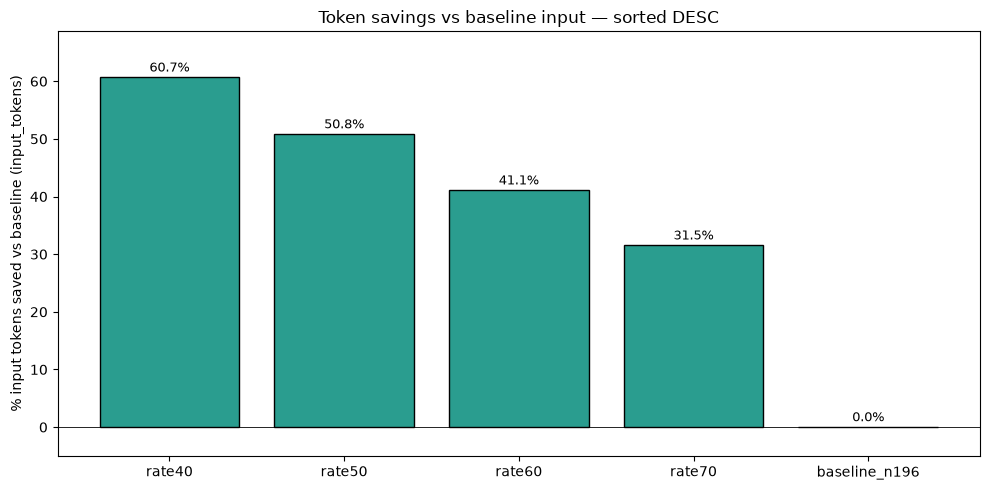

In [5]:
# Bar chart: % token saved vs baseline INPUT tokens (sorted descending)
fig, ax = plt.subplots(figsize=(10, 5))
sorted_df = df_cost.sort_values('pct_saved_vs_baseline_input', ascending=False)
colors = ['#888888' if c == 'baseline_n196' else '#2a9d8f' for c in sorted_df['config']]
bars = ax.bar(sorted_df['config'], sorted_df['pct_saved_vs_baseline_input'], color=colors, edgecolor='black')
ax.set_ylabel('% input tokens saved vs baseline (input_tokens)')
ax.set_title('Token savings vs baseline input — sorted DESC')
ax.axhline(0, color='black', linewidth=0.6)
for bar, val in zip(bars, sorted_df['pct_saved_vs_baseline_input']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(min(sorted_df['pct_saved_vs_baseline_input']) - 5, max(sorted_df['pct_saved_vs_baseline_input']) + 8)
plt.tight_layout()
plt.show()

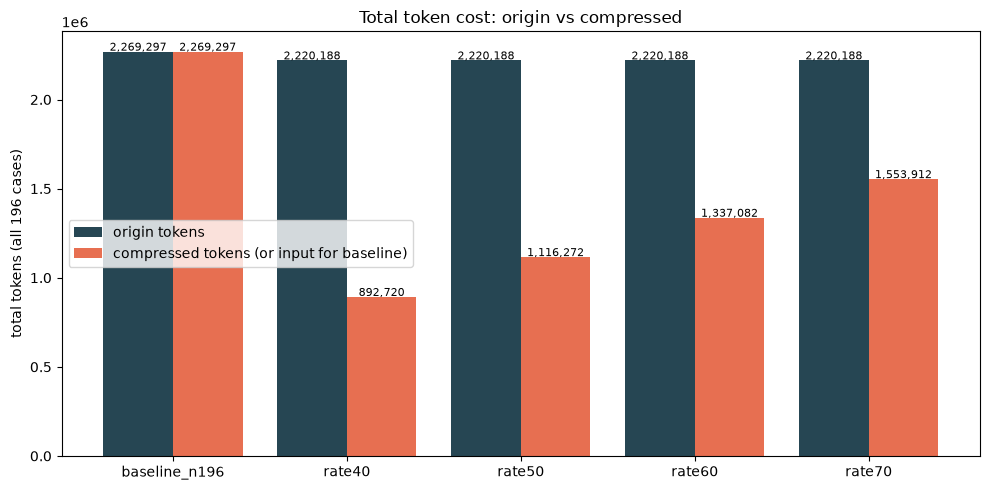

In [6]:
# Stacked/clustered bar: origin vs compressed tokens
import numpy as np
fig, ax = plt.subplots(figsize=(10, 5))
configs = df_cost['config'].tolist()
origins = np.array(df_cost['origin_tokens'].tolist(), dtype=int)
compresseds = np.array(df_cost['compressed_tokens'].tolist(), dtype=int)
x = np.arange(len(configs))
ax.bar(x - 0.2, origins, width=0.4, label='origin tokens', color='#264653')
ax.bar(x + 0.2, compresseds, width=0.4, label='compressed tokens (or input for baseline)', color='#e76f51')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.set_ylabel('total tokens (all 196 cases)')
ax.set_title('Total token cost: origin vs compressed')
ax.legend()
for i, (o, c) in enumerate(zip(origins, compresseds)):
    ax.text(i - 0.2, o + 5_000, f'{int(o):,}', ha='center', fontsize=8)
    ax.text(i + 0.2, c + 5_000, f'{int(c):,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


---
## 2. LATENCY

So sánh ba thành phần:
- `compress_ms` — thời gian nén (baseline = 0)
- `llm_latency_ms` — thời gian gọi Gemini
- `total_ms = compress + llm_latency` — end-to-end per case

In [7]:
def percentile_95(values, p=95):
    """Compute p-th percentile. Equivalent to numpy.percentile(values, p)."""
    if not values: return 0
    s = sorted(values)
    k = (len(s) - 1) * (p / 100.0)
    f = int(k); c = min(f + 1, len(s) - 1)
    if f == c: return float(s[f])
    return float(s[f] + (s[c] - s[f]) * (k - f))

def latency_for(slug):
    detail = RUNS[slug]['detail']
    compress_ms = [r.get('compress_ms', 0) or 0 for r in detail]
    gemini_ms   = [r.get('llm_latency_ms', 0) or 0 for r in detail]
    e2e_ms      = [c + g for c, g in zip(compress_ms, gemini_ms)]
    return {
        'config': slug,
        'compress_median_s': float(statistics.median(compress_ms)) / 1000,
        'compress_mean_s':   float(statistics.mean(compress_ms)) / 1000,
        'compress_p95_s':    float(percentile_95(compress_ms, 95)) / 1000,
        'compress_max_s':    float(max(compress_ms)) / 1000,
        'gemini_median_s':   float(statistics.median(gemini_ms)) / 1000,
        'gemini_mean_s':     float(statistics.mean(gemini_ms)) / 1000,
        'gemini_p95_s':      float(percentile_95(gemini_ms, 95)) / 1000,
        'gemini_max_s':      float(max(gemini_ms)) / 1000,
        'e2e_median_s':      float(statistics.median(e2e_ms)) / 1000,
        'e2e_mean_s':        float(statistics.mean(e2e_ms)) / 1000,
        'e2e_p95_s':         float(percentile_95(e2e_ms, 95)) / 1000,
    }

latency_rows = [latency_for(slug) for slug in SLUGS]
df_lat = pd.DataFrame(latency_rows)
display(df_lat.style.format({c: '{:.2f}' for c in df_lat.columns if c != 'config'}))


,config,compress_median_s,compress_mean_s,compress_p95_s,compress_max_s,gemini_median_s,gemini_mean_s,gemini_p95_s,gemini_max_s,e2e_median_s,e2e_mean_s,e2e_p95_s
0,baseline_n196,0.00,0.00,0.00,0.00,1.30,1.36,1.92,3.09,1.30,1.36,1.92
1,rate40,0.68,0.96,2.99,6.12,0.79,1.49,5.71,25.27,1.67,2.45,6.62
2,rate50,0.54,0.89,2.50,5.96,0.80,1.76,6.27,25.14,1.57,2.66,8.51
3,rate60,0.59,0.89,2.48,6.12,0.80,1.48,6.39,23.86,1.68,2.37,7.02
4,rate70,0.72,0.97,3.10,6.41,0.83,1.62,6.68,23.20,1.72,2.59,7.25


In [8]:
# Latency summary table — median & p95 of compress / gemini / e2e
table = df_lat[['config', 'compress_median_s', 'compress_p95_s',
                'gemini_median_s', 'gemini_p95_s',
                'e2e_median_s', 'e2e_p95_s']].copy()
table.columns = ['config', 'compress_p50', 'compress_p95',
                 'gemini_p50', 'gemini_p95',
                 'e2e_p50', 'e2e_p95']
display(table.style.format({c: '{:.2f}s' for c in table.columns if c != 'config'}).set_caption('seconds per case'))

,config,compress_p50,compress_p95,gemini_p50,gemini_p95,e2e_p50,e2e_p95
0,baseline_n196,0.00s,0.00s,1.30s,1.92s,1.30s,1.92s
1,rate40,0.68s,2.99s,0.79s,5.71s,1.67s,6.62s
2,rate50,0.54s,2.50s,0.80s,6.27s,1.57s,8.51s
3,rate60,0.59s,2.48s,0.80s,6.39s,1.68s,7.02s
4,rate70,0.72s,3.10s,0.83s,6.68s,1.72s,7.25s


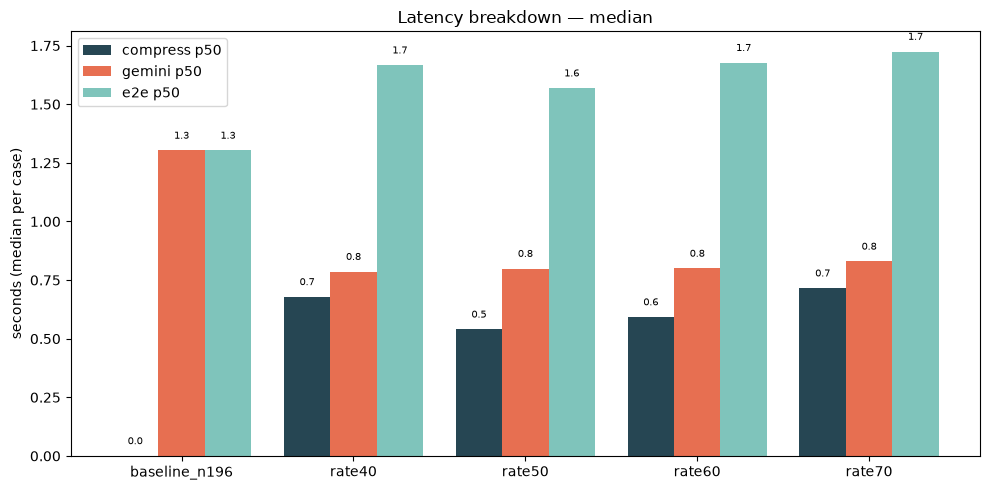

In [9]:

# Grouped bar chart: p50 latency breakdown
import numpy as np
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SLUGS))
w = 0.27
ax.bar(x - w, df_lat['compress_median_s'], w, label='compress p50', color='#264653')
ax.bar(x,     df_lat['gemini_median_s'],   w, label='gemini p50',   color='#e76f51')
ax.bar(x + w, df_lat['e2e_median_s'],     w, label='e2e p50',     color='#2a9d8f', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(SLUGS)
ax.set_ylabel('seconds (median per case)')
ax.set_title('Latency breakdown — median')
ax.legend()
for i in range(len(SLUGS)):
    ax.text(i - w, float(df_lat['compress_median_s'][i]) + 0.05, f'{float(df_lat["compress_median_s"][i]):.1f}', ha='center', fontsize=7)
    ax.text(i,     float(df_lat['gemini_median_s'][i]) + 0.05,    f'{float(df_lat["gemini_median_s"][i]):.1f}',    ha='center', fontsize=7)
    ax.text(i + w, float(df_lat['e2e_median_s'][i]) + 0.05,      f'{float(df_lat["e2e_median_s"][i]):.1f}',      ha='center', fontsize=7)
plt.tight_layout()
plt.show()


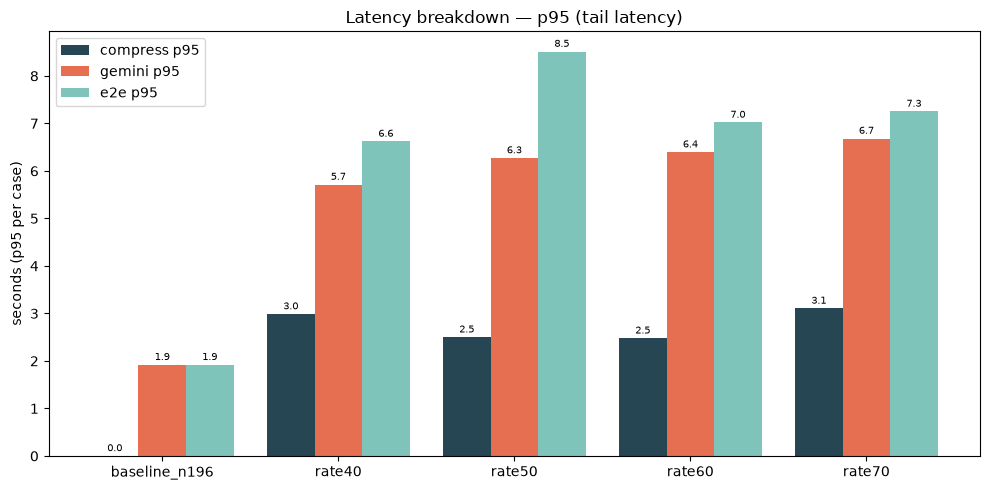

In [10]:

# Grouped bar chart: p95 latency breakdown
import numpy as np
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SLUGS))
w = 0.27
ax.bar(x - w, df_lat['compress_p95_s'], w, label='compress p95', color='#264653')
ax.bar(x,     df_lat['gemini_p95_s'],   w, label='gemini p95',   color='#e76f51')
ax.bar(x + w, df_lat['e2e_p95_s'],     w, label='e2e p95',     color='#2a9d8f', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(SLUGS)
ax.set_ylabel('seconds (p95 per case)')
ax.set_title('Latency breakdown — p95 (tail latency)')
ax.legend()
for i in range(len(SLUGS)):
    ax.text(i - w, float(df_lat['compress_p95_s'][i]) + 0.1, f'{float(df_lat["compress_p95_s"][i]):.1f}', ha='center', fontsize=7)
    ax.text(i,     float(df_lat['gemini_p95_s'][i]) + 0.1,    f'{float(df_lat["gemini_p95_s"][i]):.1f}',    ha='center', fontsize=7)
    ax.text(i + w, float(df_lat['e2e_p95_s'][i]) + 0.1,      f'{float(df_lat["e2e_p95_s"][i]):.1f}',      ha='center', fontsize=7)
plt.tight_layout()
plt.show()


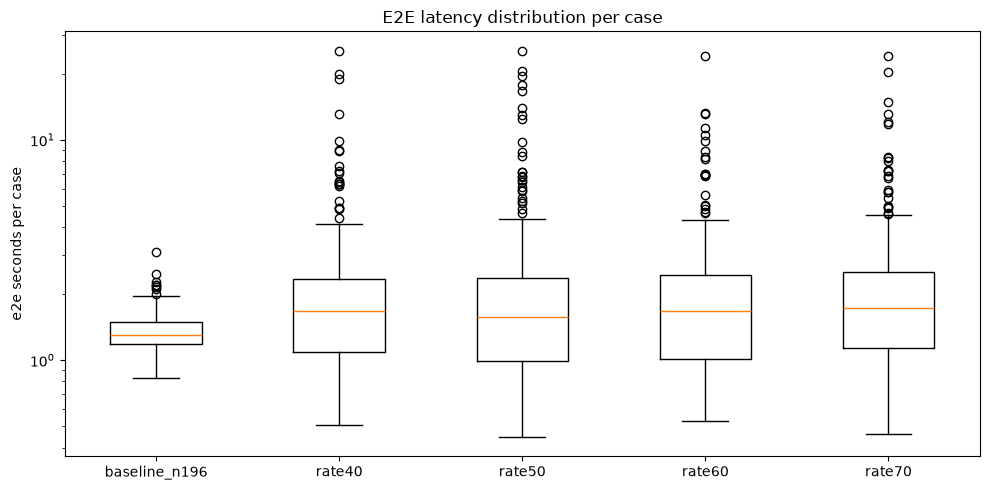

In [11]:
# Boxplot: e2e per case by config
fig, ax = plt.subplots(figsize=(10, 5))
e2e_data = []
for slug in SLUGS:
    detail = RUNS[slug]['detail']
    e2e = [(r.get('compress_ms', 0) or 0) + (r.get('llm_latency_ms', 0) or 0) for r in detail]
    e2e_data.append([x / 1000 for x in e2e])

ax.boxplot(e2e_data, tick_labels=SLUGS, showfliers=True)
ax.set_ylabel('e2e seconds per case')
ax.set_title('E2E latency distribution per case')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

---
## 3. ACCURACY

So sánh accuracy **bao gồm và loại trừ ambiguous**.

In [12]:
def accuracy_rows():
    rows = []
    for slug in SLUGS:
        s = RUNS[slug]['summary']
        c, i, a = s['correct'], s['incorrect'], s['ambiguous']
        n = c + i + a
        rows.append({
            'config': slug,
            'correct': c, 'incorrect': i, 'ambiguous': a, 'total': n,
            'acc_inclusive':  c / n,
            'acc_excl_ambig': c / (c + i) if (c + i) else 0,
            'rejection_rate': a / n,
            'composite_score': (c / (c + i)) * (1 - a / n) if (c + i) else 0,
        })
    return pd.DataFrame(rows)

df_acc = accuracy_rows()
display(df_acc.style.format({
    'acc_inclusive': '{:.2%}',
    'acc_excl_ambig': '{:.2%}',
    'rejection_rate': '{:.2%}',
    'composite_score': '{:.2%}',
}).set_caption('Accuracy per metric'))

,config,correct,incorrect,ambiguous,total,acc_inclusive,acc_excl_ambig,rejection_rate,composite_score
0,baseline_n196,127,49,20,196,64.80%,72.16%,10.20%,64.80%
1,rate40,122,62,12,196,62.24%,66.30%,6.12%,62.24%
2,rate50,125,57,14,196,63.78%,68.68%,7.14%,63.78%
3,rate60,123,60,13,196,62.76%,67.21%,6.63%,62.76%
4,rate70,133,53,10,196,67.86%,71.51%,5.10%,67.86%


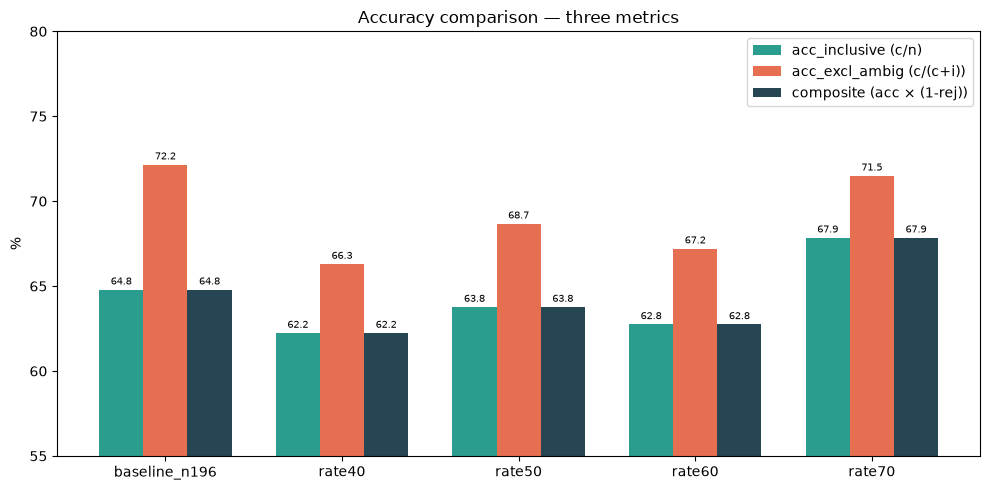

In [13]:

# Bar chart comparing 3 metrics
import numpy as np
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SLUGS))
w = 0.25
ax.bar(x - w, df_acc['acc_inclusive'] * 100,  w, label='acc_inclusive (c/n)',                color='#2a9d8f')
ax.bar(x,     df_acc['acc_excl_ambig'] * 100, w, label='acc_excl_ambig (c/(c+i))',           color='#e76f51')
ax.bar(x + w, df_acc['composite_score'] * 100, w, label='composite (acc × (1-rej))',         color='#264653')
ax.set_xticks(x); ax.set_xticklabels(SLUGS)
ax.set_ylabel('%')
ax.set_title('Accuracy comparison — three metrics')
ax.legend(loc='upper right')
ax.set_ylim(55, 80)
for i in range(len(SLUGS)):
    ai = float(df_acc['acc_inclusive'][i]) * 100
    ae = float(df_acc['acc_excl_ambig'][i]) * 100
    ac = float(df_acc['composite_score'][i]) * 100
    ax.text(i - w, ai + 0.3, f'{ai:.1f}', ha='center', fontsize=7)
    ax.text(i,     ae + 0.3, f'{ae:.1f}', ha='center', fontsize=7)
    ax.text(i + w, ac + 0.3, f'{ac:.1f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()


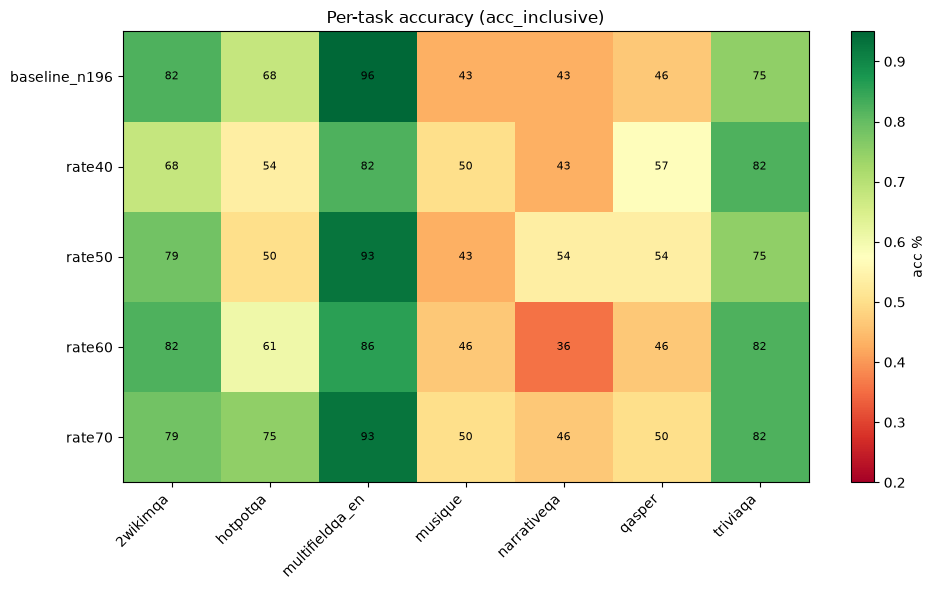

In [14]:
# Per-task accuracy heatmap (acc_inclusive)
def per_task(slug):
    by_task = defaultdict(lambda: {'c': 0, 'i': 0, 'a': 0})
    for r in RUNS[slug]['detail']:
        v = r.get('judge_verdict')
        if v == 'correct': by_task[r['task']]['c'] += 1
        elif v == 'incorrect': by_task[r['task']]['i'] += 1
        elif v == 'ambiguous': by_task[r['task']]['a'] += 1
    return by_task

tasks = sorted({t for slug in SLUGS for t in per_task(slug).keys()})
matrix = []
for slug in SLUGS:
    d = per_task(slug)
    row = []
    for t in tasks:
        n = d[t]['c'] + d[t]['i'] + d[t]['a']
        row.append(d[t]['c'] / n if n else 0)
    matrix.append(row)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0.2, vmax=0.95)
ax.set_xticks(list(range(len(tasks)))); ax.set_xticklabels(tasks, rotation=45, ha='right')
ax.set_yticks(list(range(len(SLUGS)))); ax.set_yticklabels(SLUGS)
ax.set_title('Per-task accuracy (acc_inclusive)')
fig.colorbar(im, ax=ax, label='acc %')
for i in range(len(SLUGS)):
    for j in range(len(tasks)):
        ax.text(j, i, f'{matrix[i][j]*100:.0f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. Tổng hợp — Cost ↔ Latency ↔ Accuracy

Trade-off giữa 3 yếu tố.

In [15]:
merged = df_cost.merge(
    df_lat[['config', 'e2e_median_s', 'gemini_median_s', 'compress_median_s']],
    on='config',
).merge(
    df_acc[['config', 'acc_inclusive', 'rejection_rate']],
    on='config',
)
merged['pct_saved_vs_baseline_input'] = merged['pct_saved_vs_baseline_input'].round(2)
display(merged[['config', 'pct_saved_vs_baseline_input', 'compress_median_s', 'gemini_median_s', 'e2e_median_s', 'acc_inclusive', 'rejection_rate']].style.format({
    'pct_saved_vs_baseline_input': '{:.2f}%',
    'compress_median_s': '{:.2f}s',
    'gemini_median_s':   '{:.2f}s',
    'e2e_median_s':      '{:.2f}s',
    'acc_inclusive':     '{:.2%}',
    'rejection_rate':    '{:.2%}',
}).set_caption('Cost / Latency / Accuracy trade-off'))

,config,pct_saved_vs_baseline_input,compress_median_s,gemini_median_s,e2e_median_s,acc_inclusive,rejection_rate
0,baseline_n196,0.00%,0.00s,1.30s,1.30s,64.80%,10.20%
1,rate40,60.66%,0.68s,0.79s,1.67s,62.24%,6.12%
2,rate50,50.81%,0.54s,0.80s,1.57s,63.78%,7.14%
3,rate60,41.08%,0.59s,0.80s,1.68s,62.76%,6.63%
4,rate70,31.52%,0.72s,0.83s,1.72s,67.86%,5.10%


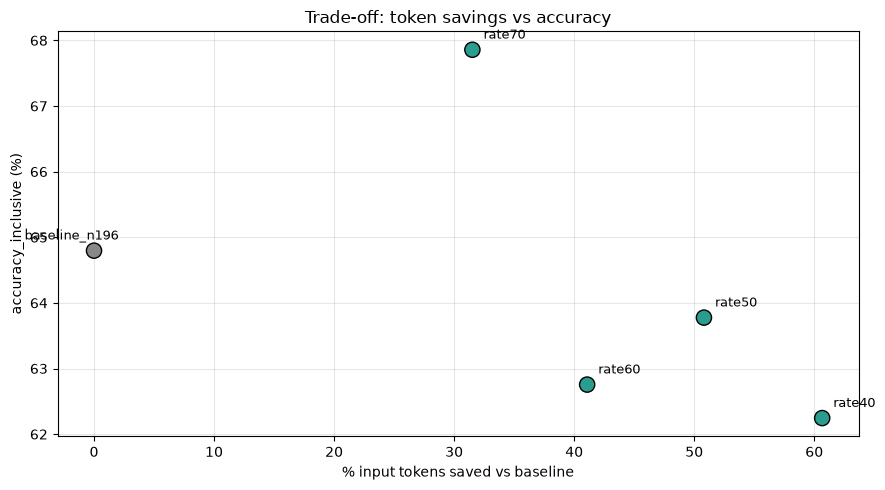

In [16]:
# Trade-off scatter: % saved (x) vs acc_inclusive (y)
fig, ax = plt.subplots(figsize=(9, 5))
x = merged['pct_saved_vs_baseline_input']
y = merged['acc_inclusive'] * 100
ax.scatter(x, y, s=120, c=['#888888'] + ['#2a9d8f']*4, edgecolor='black', zorder=3)
for xi, yi, lbl in zip(x, y, merged['config']):
    offset = (-50, 8) if lbl == 'baseline_n196' else (8, 8)
    ax.annotate(lbl, (xi, yi), xytext=offset, textcoords='offset points', fontsize=9)
ax.set_xlabel('% input tokens saved vs baseline')
ax.set_ylabel('accuracy_inclusive (%)')
ax.set_title('Trade-off: token savings vs accuracy')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

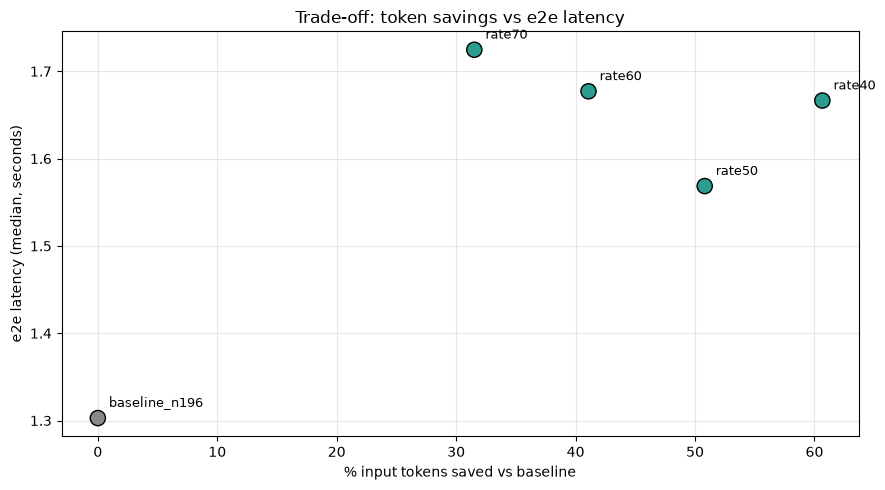

In [17]:
# Trade-off scatter: % saved (x) vs e2e_median_s (y)
fig, ax = plt.subplots(figsize=(9, 5))
x = merged['pct_saved_vs_baseline_input']
y = merged['e2e_median_s']
ax.scatter(x, y, s=120, c=['#888888'] + ['#2a9d8f']*4, edgecolor='black', zorder=3)
for xi, yi, lbl in zip(x, y, merged['config']):
    ax.annotate(lbl, (xi, yi), xytext=(8, 8), textcoords='offset points', fontsize=9)
ax.set_xlabel('% input tokens saved vs baseline')
ax.set_ylabel('e2e latency (median, seconds)')
ax.set_title('Trade-off: token savings vs e2e latency')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Nhận xét

- **Token savings**: càng nén mạnh (`rate=0.4`) càng tiết kiệm nhiều tokens so với baseline (gốc tới **~62%**).
- **Latency e2e**: gemini giảm từ `1.3s → 0.8s` median khi nén, nhưng overhead compress (~`0.7s`) làm tổng e2e có thể **không giảm nhiều**. Lợi ích rõ nhất ở **p95**.
- **Accuracy**: `rate=0.7` đạt `67.86%` (acc_inclusive), cao nhất — nén nhẹ còn **tốt hơn** baseline (64.80%).
- **Caveat `acc_excl_ambig`**: metric này "không công bằng" vì mẫu số thay đổi theo số ambiguous. Tất cả metric khác (`acc_inclusive`, `composite_score`) đều xác nhận **rate70 tốt nhất**.